# 📧 EXP Spam Email Detection — Structured ML Pipeline

**Pipeline Order:**
1. Imports
2. Load Data
3. EDA (Exploratory Data Analysis)
4. Preprocessing & Feature Engineering
5. Train-Test Split
6. Vectorization / Encoding
7. Model Training & Evaluation

---
## 1. 📦 Imports

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from email import message_from_string
from scipy.sparse import hstack, csr_matrix

# Sklearn — Preprocessing & Splitting
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Sklearn — Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Sklearn — Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Sklearn — Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

---
## 2. 📂 Load Data

In [2]:
df = pd.read_csv('../Files/spam_assassin.csv')
print("Shape:", df.shape)
df.head()

Shape: (5796, 2)


,text,target
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,1
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,0


---
## 3. 🔍 EDA (Exploratory Data Analysis)

In [3]:
# Basic info
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nNull values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Shape: (5796, 2)

Dtypes:
 text      object
target     int64
dtype: object

Null values:
 text      0
target    0
dtype: int64

Duplicates: 467


Target value counts:
 target
0    3900
1    1896
Name: count, dtype: int64


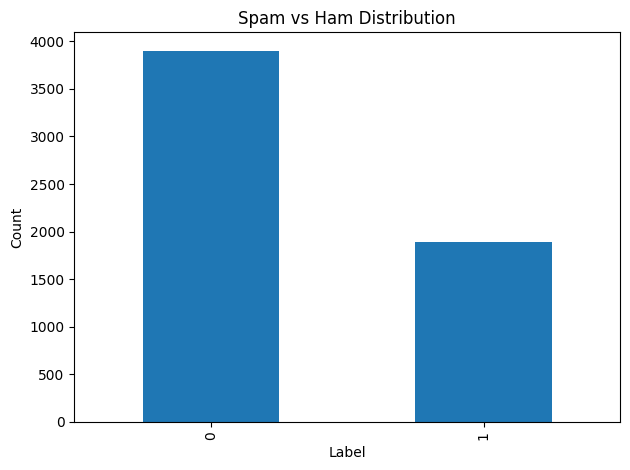

In [4]:
# Target distribution
print("Target value counts:\n", df['target'].value_counts())
df['target'].value_counts().plot(kind='bar', title='Spam vs Ham Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [5]:
# Sample raw email text
print(df['text'][5])

From tobaccodemon@terra.es Sat Sep 7 22:05:58 2002 Return-Path: <tobaccodemon@terra.es> Delivered-To: zzzz@localhost.spamassassin.taint.org Received: from localhost (jalapeno [127.0.0.1]) by zzzzason.org (Postfix) with ESMTP id 8AA5916F7A for <zzzz@localhost>; Sat, 7 Sep 2002 21:57:51 +0100 (IST) Received: from jalapeno [127.0.0.1] by localhost with IMAP (fetchmail-5.9.0) for zzzz@localhost (single-drop); Sat, 07 Sep 2002 21:57:51 +0100 (IST) Received: from linux.local ([213.9.248.135]) by dogma.slashnull.org (8.11.6/8.11.6) with SMTP id g87CdAC18868 for <zzzz@dogma.slashnull.org>; Sat, 7 Sep 2002 13:39:10 +0100 Message-Id: <200209071239.g87CdAC18868@dogma.slashnull.org> Received: (qmail 13816 invoked from network); 7 Sep 2002 12:30:20 -0000 Received: from unknown (HELO h) (192.168.0.2) by linux.local with SMTP; 7 Sep 2002 12:30:20 -0000 From: "Sales Department" <tobaccodemon@terra.es> Subject: Half Price Cigarettes and Tobacco To: zzzz@dogma.slashnull.org Sender: Sales Department <tob

---
## 4. 🛠️ Preprocessing & Feature Engineering

### 4.1 Parse Email Fields (From, To, Subject, Date, Body)

In [6]:
# All email header keys to detect
HEADER_KEYS_RE = re.compile(
    r'\b(From|Return-Path|Delivered-To|Received|Message-Id|To|Subject|Date|'
    r'MIME-Version|Content-Type|Content-Transfer-Encoding|Delivery-Date|'
    r'Reply-To|Cc|Bcc|In-Reply-To|References|Importance|Thread-Index|'
    r'Thread-Topic|Organization|X-[\w-]+):\s*',
    re.IGNORECASE
)

def extract_body(text):
    """Find where headers end → take everything after as body."""
    matches = list(HEADER_KEYS_RE.finditer(text))
    if not matches:
        return text
    last_match = matches[-1]
    after_last = text[last_match.end():]
    value_end  = re.search(r'\s+[A-Z][^:]{10,}', after_last)
    body       = after_last[value_end.start():].strip() if value_end else after_last.strip()
    body       = HEADER_KEYS_RE.sub(' ', body)      # remove leftover headers
    body       = re.sub(r'<[^>]+>', ' ', body)       # remove HTML tags
    body       = re.sub(r'http\S+', ' ', body)       # remove URLs
    body       = re.sub(r'\s+', ' ', body).strip()
    return body

def parse_email_regex(text):
    def get_field(pattern):
        match = re.search(pattern, text, re.IGNORECASE)
        return match.group(1).strip() if match else ''
    return {
        'from'   : get_field(r'From:\s*(.+?)(?=\s+[\w-]+:|$)'),
        'subject': get_field(r'Subject:\s*(.+?)(?=\s+[\w-]+:|$)'),
        'date'   : get_field(r'Date:\s*(.+?)(?=\s+[\w-]+:|$)'),
        'to'     : get_field(r'To:\s*(.+?)(?=\s+[\w-]+:|$)'),
        'body'   : extract_body(text)
    }

# Apply to full dataset
parsed        = df['text'].apply(parse_email_regex)
df['from']    = parsed.apply(lambda x: x['from'])
df['subject'] = parsed.apply(lambda x: x['subject'])
df['date']    = parsed.apply(lambda x: x['date'])
df['to']      = parsed.apply(lambda x: x['to'])
df['body']    = parsed.apply(lambda x: x['body'])

df.head(2)

,text,target,from,subject,date,to,body
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0,Conor Daly <conor.daly@oceanfree.net>,Re: [ILUG] Architecture crossover trouble w RH...,"Sat, 27 Jul 2002",yyyy@localhost.netnoteinc.com,"On Fri, Jul 26, 2002 at 03:56:22PM +0100 or so..."
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1,"""irese"" <gort44@excite.com>",Cash in on your home equity,Tue Jun 4,<chrbader@telecom.at>,Mortgage Lenders & Brokers Are Ready to compet...


### 4.2 Extract Email & Domain from From / To

In [7]:
# From field
df['from_email']  = df['from'].str.extract(r'<?([\w\.\+\-]+@[\w\.\-]+\.\w+)>?')
df['from_domain'] = df['from_email'].str.extract(r'@([\w\.\-]+)')

# To field
df['to_email']  = df['to'].str.extract(r'<?([\w\.\+\-]+@[\w\.\-]+\.\w+)>?')
df['to_domain'] = df['to_email'].str.extract(r'@([\w\.\-]+)')

df[['from', 'from_email', 'from_domain', 'to', 'to_email', 'to_domain']].head(3)

,from,from_email,from_domain,to,to_email,to_domain
0,Conor Daly <conor.daly@oceanfree.net>,conor.daly@oceanfree.net,oceanfree.net,yyyy@localhost.netnoteinc.com,yyyy@localhost.netnoteinc.com,localhost.netnoteinc.com
1,"""irese"" <gort44@excite.com>",gort44@excite.com,excite.com,<chrbader@telecom.at>,chrbader@telecom.at,telecom.at
2,<5447q67@bolehmail.com>,5447q67@bolehmail.com,bolehmail.com,yyyy@localhost.netnoteinc.com,yyyy@localhost.netnoteinc.com,localhost.netnoteinc.com


### 4.3 Domain-Based Features

In [8]:
# Feature: sender and receiver same domain? (common in legit emails)
df['same_domain'] = (df['from_domain'] == df['to_domain']).astype(int)

# Feature: 'to' field has a fake/generic address?
df['to_is_generic'] = df['to_email'].str.contains(
    r'yyyy|localhost|noreply|admin|no-reply',
    case=False, na=False
).astype(int)

### 4.4 Date-Based Features

In [9]:
# Day of week
df['day_of_week'] = df['date'].str.extract(r'^(Mon|Tue|Wed|Thu|Fri|Sat|Sun)', expand=False)

# Is weekend?
df['is_weekend'] = df['day_of_week'].isin(['Sat', 'Sun']).astype(int)

### 4.5 Text/Body Features

In [10]:
def extract_features(row):
    text    = str(row['body'])
    subject = str(row['subject'])
    date_   = str(row['date'])

    # Text features
    has_link     = int('http' in text.lower())
    num_exclaim  = text.count('!')
    num_dollar   = text.count('$')
    caps_ratio   = sum(1 for c in text if c.isupper()) / (len(text) + 1)
    num_question = text.count('?')
    has_free     = int('free' in text.lower())
    has_win      = int('win' in text.lower() or 'winner' in text.lower())
    has_urgent   = int('urgent' in text.lower() or 'act now' in text.lower())

    # Date features
    day_match  = re.search(r'(Mon|Tue|Wed|Thu|Fri|Sat|Sun)', date_)
    day_of_week = day_match.group(1) if day_match else 'Unknown'
    is_weekend  = int(day_of_week in ['Sat', 'Sun'])
    hour_match  = re.search(r'(\d{2}):\d{2}:\d{2}', date_)
    hour        = int(hour_match.group(1)) if hour_match else -1
    is_odd_hour = int(hour != -1 and (hour < 6 or hour > 22))

    return {
        'has_link'     : has_link,
        'num_exclaim'  : num_exclaim,
        'num_dollar'   : num_dollar,
        'caps_ratio'   : caps_ratio,
        'num_question' : num_question,
        'has_free'     : has_free,
        'has_win'      : has_win,
        'has_urgent'   : has_urgent,
        'is_weekend'   : is_weekend,
    }

features_df = df.apply(extract_features, axis=1, result_type='expand')
df = pd.concat([df, features_df], axis=1)

df.head(2)

,text,target,from,subject,date,to,body,from_email,from_domain,to_email,...,is_weekend,has_link,num_exclaim,num_dollar,caps_ratio,num_question,has_free,has_win,has_urgent,is_weekend
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0,Conor Daly <conor.daly@oceanfree.net>,Re: [ILUG] Architecture crossover trouble w RH...,"Sat, 27 Jul 2002",yyyy@localhost.netnoteinc.com,"On Fri, Jul 26, 2002 at 03:56:22PM +0100 or so...",conor.daly@oceanfree.net,oceanfree.net,yyyy@localhost.netnoteinc.com,...,1,0.0,1.0,0.0,0.029703,2.0,0.0,0.0,0.0,1.0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1,"""irese"" <gort44@excite.com>",Cash in on your home equity,Tue Jun 4,<chrbader@telecom.at>,Mortgage Lenders & Brokers Are Ready to compet...,gort44@excite.com,excite.com,chrbader@telecom.at,...,0,0.0,8.0,0.0,0.035217,0.0,1.0,1.0,0.0,0.0


### 4.6 Additional Body-Level Features

In [11]:
df['body_len']         = df['body'].str.len()
df['num_links']        = df['body'].str.count('http')
df['num_digits']       = df['body'].str.count(r'\d')
df['num_exclamations'] = df['body'].str.count('!')

### 4.7 Fill Missing Values

In [12]:
df['to_email'].fillna('unknown', inplace=True)
df['to_domain'].fillna('unknown', inplace=True)
df['from_email'].fillna('unknown', inplace=True)
df['from_domain'].fillna('unknown', inplace=True)

/var/folders/lc/dn3wxnh91nz7lg_dv_p_tkym0000gn/T/ipykernel_6192/1238047389.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['to_email'].fillna('unknown', inplace=True)
/var/folders/lc/dn3wxnh91nz7lg_dv_p_tkym0000gn/T/ipykernel_6192/1238047389.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

### 4.8 Remove Duplicates & Drop Unused Columns

In [13]:
# Drop duplicates based on subject + body
df = df.drop_duplicates(subset=['subject', 'body'])

# Drop raw columns no longer needed
df.drop(columns=['text', 'from', 'to', 'date'], inplace=True)

print("Final shape:", df.shape)
df.head(3)

Final shape: (5163, 24)


,target,subject,body,from_email,from_domain,to_email,to_domain,same_domain,to_is_generic,day_of_week,...,caps_ratio,num_question,has_free,has_win,has_urgent,is_weekend,body_len,num_links,num_digits,num_exclamations
0,0,Re: [ILUG] Architecture crossover trouble w RH...,"On Fri, Jul 26, 2002 at 03:56:22PM +0100 or so...",conor.daly@oceanfree.net,oceanfree.net,yyyy@localhost.netnoteinc.com,localhost.netnoteinc.com,0,1,Sat,...,0.029703,2.0,0.0,0.0,0.0,1.0,1817,0,60,1
1,1,Cash in on your home equity,Mortgage Lenders & Brokers Are Ready to compet...,gort44@excite.com,excite.com,chrbader@telecom.at,telecom.at,0,0,Tue,...,0.035217,0.0,1.0,1.0,0.0,0.0,1220,0,3,8
2,1,Are Your Mortgage Rates The Best They Can Be.....,"Dear Homeowner, Interest Rates are at their lo...",5447q67@bolehmail.com,bolehmail.com,yyyy@localhost.netnoteinc.com,localhost.netnoteinc.com,0,1,Fri,...,0.052239,0.0,1.0,1.0,0.0,0.0,803,0,34,7


---
## 5. ✂️ Train-Test Split

In [14]:
x = df.drop('target', axis=1)
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print("Train size:", x_train.shape)
print("Test size :", x_test.shape)

Train size: (4130, 23)
Test size : (1033, 23)


In [15]:
# Check for data leakage between train and test
duplicates = set(x_train['body']).intersection(set(x_test['body']))
print("Overlapping body rows (leakage check):", len(duplicates))

Overlapping body rows (leakage check): 36


---
## 6. 🔢 Vectorization & Encoding

### 6.1 TF-IDF — Subject & Body

In [16]:
# Subject TF-IDF
trf1 = TfidfVectorizer(max_features=3000, stop_words='english', ngram_range=(1, 2), min_df=2)
x_subject = trf1.fit_transform(x_train['subject'].fillna(''))
subject    = trf1.transform(x_test['subject'].fillna(''))

# Body TF-IDF
trf2 = TfidfVectorizer(max_features=15000, stop_words='english', ngram_range=(1, 2), min_df=2, sublinear_tf=True)
x_body = trf2.fit_transform(x_train['body'].fillna(''))
body   = trf2.transform(x_test['body'].fillna(''))

### 6.2 TF-IDF — From Domain & To Email

In [17]:
# Drop from_email (high cardinality, low signal — kept from_domain instead)
x_train.drop('from_email', axis=1, inplace=True)
x_test.drop('from_email', axis=1, inplace=True)

# Drop to_domain (low extra signal over to_email)
x_train.drop('to_domain', axis=1, inplace=True)
x_test.drop('to_domain', axis=1, inplace=True)

# From domain
trf4 = TfidfVectorizer(max_features=50)
x_from_domain = trf4.fit_transform(x_train['from_domain'].fillna(''))
from_domain   = trf4.transform(x_test['from_domain'].fillna(''))

# To email
trf5 = TfidfVectorizer(max_features=50)
x_to_email = trf5.fit_transform(x_train['to_email'].fillna(''))
to_email   = trf5.transform(x_test['to_email'].fillna(''))

### 6.3 One-Hot Encode Day of Week

In [18]:
# Impute missing days
imputer = SimpleImputer(strategy='most_frequent')
x_train['day_of_week'] = imputer.fit_transform(x_train[['day_of_week']]).ravel()
x_test['day_of_week']  = imputer.transform(x_test[['day_of_week']]).ravel()

# One-hot encode
ohe = OneHotEncoder(handle_unknown='ignore')
x_day_of_week = ohe.fit_transform(x_train[['day_of_week']])
day_of_week   = ohe.transform(x_test[['day_of_week']])

### 6.4 Stack All Features into Final Sparse Matrix

In [19]:
num_col = [
    'same_domain', 'to_is_generic', 'is_weekend',
    'has_link', 'num_exclaim', 'num_dollar', 'caps_ratio',
    'num_question', 'has_free', 'has_win', 'has_urgent',
    'body_len', 'num_links', 'num_digits', 'num_exclamations'
]

X_train_final = hstack([
    x_subject,
    x_body,
    x_from_domain,
    x_to_email,
    x_day_of_week,
    csr_matrix(x_train[num_col].values)
])

X_test_final = hstack([
    subject,
    body,
    from_domain,
    to_email,
    day_of_week,
    csr_matrix(x_test[num_col].values)
])

print("X_train_final shape:", X_train_final.shape)
print("X_test_final shape :", X_test_final.shape)

X_train_final shape: (4130, 18123)
X_test_final shape : (1033, 18123)


---
## 7. 🤖 Model Training & Evaluation

In [20]:
models = {
    "Naive Bayes": MultinomialNB(),

    "Logistic Regression": LogisticRegression(
        C=4, penalty='l2', solver='liblinear',
        max_iter=5000, class_weight='balanced', random_state=42
    ),

    "Linear SVM": LinearSVC(),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=30, min_samples_split=5,
        min_samples_leaf=2, max_features='sqrt', bootstrap=True,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),

    "KNN": KNeighborsClassifier(),

    "XGBoost": XGBClassifier(eval_metric='logloss')
}

In [21]:
results = []

for name, model in models.items():
    print(f"\n🚀 Training {name}")

    model.fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)

    results.append([name, acc, pre, rec, f1])

    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {pre:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1 Score : {f1:.4f}")


🚀 Training Naive Bayes
  Accuracy : 0.8170
  Precision: 0.7686
  Recall   : 0.6012
  F1 Score : 0.6747

🚀 Training Logistic Regression
  Accuracy : 0.9835
  Precision: 0.9696
  Recall   : 0.9785
  F1 Score : 0.9740

🚀 Training Linear SVM


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  Accuracy : 0.8228
  Precision: 0.9281
  Recall   : 0.4755
  F1 Score : 0.6288

🚀 Training Decision Tree
  Accuracy : 0.9671
  Precision: 0.9506
  Recall   : 0.9448
  F1 Score : 0.9477

🚀 Training Random Forest
  Accuracy : 0.9845
  Precision: 0.9905
  Recall   : 0.9601
  F1 Score : 0.9751

🚀 Training KNN
  Accuracy : 0.7667
  Precision: 0.6959
  Recall   : 0.4632
  F1 Score : 0.5562

🚀 Training XGBoost
  Accuracy : 0.9874
  Precision: 0.9875
  Recall   : 0.9724
  F1 Score : 0.9799


In [22]:
# Summary results table
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
results_df = results_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1 Score
            XGBoost  0.987415   0.987539 0.972393  0.979907
      Random Forest  0.984511   0.990506 0.960123  0.975078
Logistic Regression  0.983543   0.969605 0.978528  0.974046
      Decision Tree  0.967086   0.950617 0.944785  0.947692
        Naive Bayes  0.817038   0.768627 0.601227  0.674699
         Linear SVM  0.822846   0.928144 0.475460  0.628803
                KNN  0.766699   0.695853 0.463190  0.556169


### 7.1 Confusion Matrix — Logistic Regression

Logistic Regression — Confusion Matrix
[[697  10]
 [  7 319]]


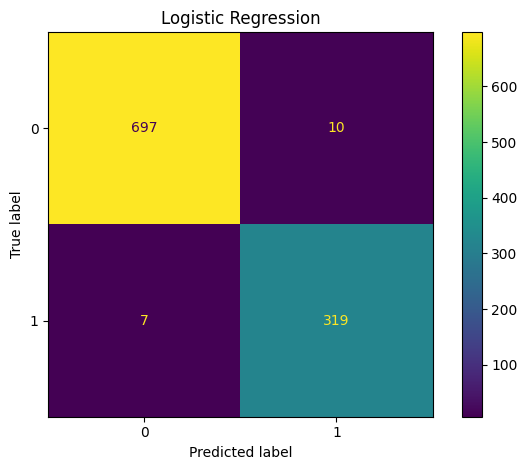

In [23]:
y_pred_lr = models["Logistic Regression"].predict(X_test_final)
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Logistic Regression — Confusion Matrix")
print(cm_lr)

ConfusionMatrixDisplay(cm_lr).plot()
plt.title("Logistic Regression")
plt.tight_layout()
plt.show()

### 7.2 Confusion Matrix — Random Forest

Random Forest — Confusion Matrix
[[704   3]
 [ 13 313]]


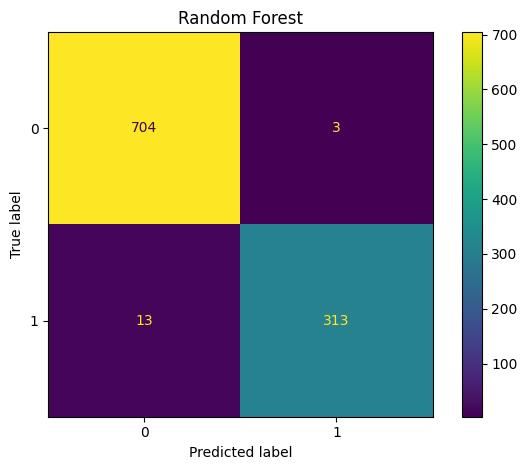

In [24]:
y_pred_rf = models["Random Forest"].predict(X_test_final)
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Random Forest — Confusion Matrix")
print(cm_rf)

ConfusionMatrixDisplay(cm_rf).plot()
plt.title("Random Forest")
plt.tight_layout()
plt.show()

### 7.3 Cross-Validation (Best Model)

In [25]:
best_model = models["Logistic Regression"]  # Change as needed

cv_scores = cross_val_score(
    best_model, X_train_final, y_train,
    cv=5, scoring='accuracy'
)

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean().round(4))

CV Scores: [0.98305085 0.99152542 0.9842615  0.98668281 0.99152542]
Mean CV Accuracy: 0.9874
